# 1.Naïve Bayes Classifier


In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Load dataset
data = load_breast_cancer(as_frame=True)
df = data.frame

print(f"Dataset loaded successfully with shape: {df.shape}")

# Splitting features and target
X = df.drop('target', axis=1)
y = df['target']

# Train-test split (80-20)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {x_train.shape}, Testing data shape: {x_test.shape}")

# Create and train model
model = GaussianNB()
model.fit(x_train, y_train)

# Predictions
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n--- Model Evaluation ---\n")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC Score: {auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)

# Cross-validation (k=10)
cv_scores = cross_val_score(model, X, y, cv=10, scoring='accuracy')
print(f"\nCross-validation Accuracy (10-fold): {cv_scores.mean():.4f}")

Dataset loaded successfully with shape: (569, 31)
Training data shape: (455, 30), Testing data shape: (114, 30)

--- Model Evaluation ---

Accuracy: 0.9737
AUC Score: 0.9984

Confusion Matrix:
[[40  3]
 [ 0 71]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Cross-validation Accuracy (10-fold): 0.9368


# 2 (a) Simple Linear Regression


Data loaded successfully with shape: (20640, 9)


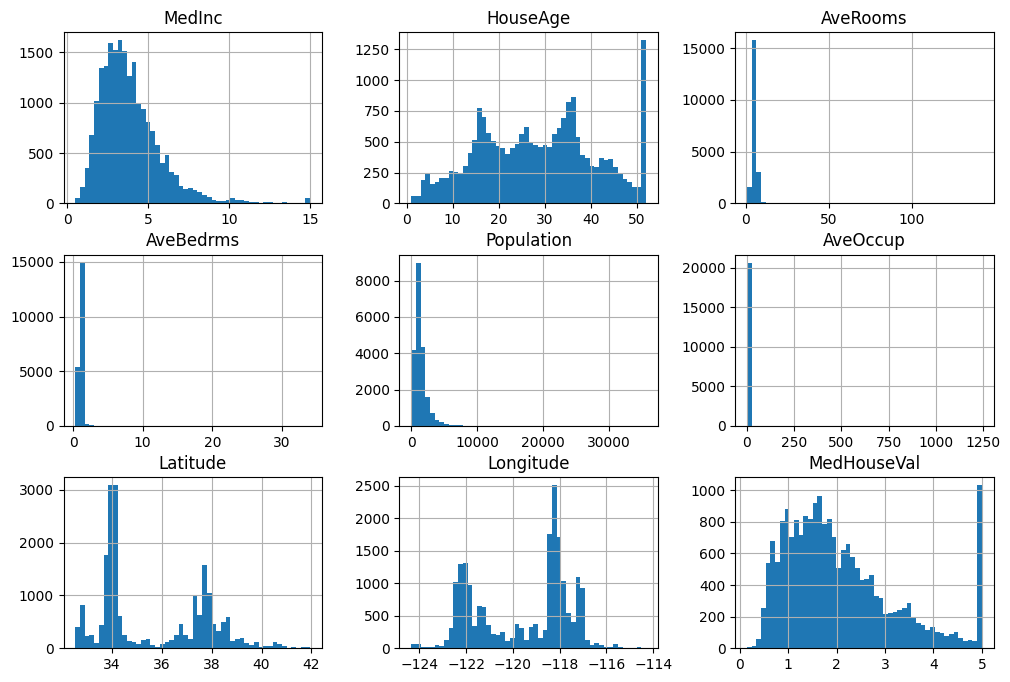

Training data shape: (18576, 8)
Testing data shape: (2064, 8)

--- Model Evaluation ---
Model Intercept (B): -36.7196
Model Coefficients (M): [ 4.41643302e-01  9.57511565e-03 -1.10367141e-01  6.52574143e-01
 -4.32296453e-06 -3.61976686e-03 -4.18702648e-01 -4.31747018e-01]
Mean Squared Error: 0.5590
R-squared: 0.5808

Cross-validation R2 scores: [0.54866323 0.46820691 0.55078434 0.53698703 0.66051406]
Mean CV R2 score: 0.5530311140279569

Predicted house value (in 100k): $1.76
Predicted house value (actual): $175,506.41


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



Selected Features: ['MedInc', 'HouseAge', 'Latitude', 'Longitude']
Model R² score with selected features: 0.5718
Cross-validation R2 scores (selected features): [0.61107614 0.58595256 0.59261176 0.60788297 0.58451879]
Mean CV R2 score: 0.5964084458093544

Original number of features: 8
Number of components (95% variance): 6
Explained variance ratio: [0.25351093 0.2346866  0.15922551 0.12860831 0.12546505 0.08281622]

Model R² score using PCA: 0.4830
Cross-validation R2 scores (PCA): [0.45718681 0.37999705 0.47471982 0.34685988 0.49941592]
Mean CV R2 score: 0.4316358937570812


In [ ]:
# ===================== IMPORT LIBRARIES =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ===================== LOAD DATASET =====================
housing = fetch_california_housing(as_frame=True)
house_price_df = housing.frame

print(f"Data loaded successfully with shape: {house_price_df.shape}")

# ===================== DATA VISUALIZATION =====================
house_price_df.hist(bins=50, figsize=(12, 8))
plt.show()

# ===================== FEATURE & TARGET =====================
X = house_price_df.drop('MedHouseVal', axis=1)
y = house_price_df['MedHouseVal']

# ===================== TRAIN-TEST SPLIT =====================
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")

# ===================== MODEL TRAINING =====================
model = LinearRegression()
model.fit(x_train, y_train)

# ===================== PREDICTIONS =====================
y_pred = model.predict(x_test)

# ===================== EVALUATION =====================
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Model Intercept (B): {model.intercept_:.4f}")
print(f"Model Coefficients (M): {model.coef_}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

# ===================== CROSS VALIDATION =====================
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("\nCross-validation R2 scores:", cv_scores)
print("Mean CV R2 score:", cv_scores.mean())

# ===================== SAMPLE PREDICTION =====================
sample_house = np.array([[2.5313, 30.0, 5.039384, 1.193493,
                          1565.0, 2.679795, 35.14, -119.46]])

predicted_price_100k = model.predict(sample_house)
predicted_price_actual = predicted_price_100k[0] * 100000

print(f"\nPredicted house value (in 100k): ${predicted_price_100k[0]:.2f}")
print(f"Predicted house value (actual): ${predicted_price_actual:,.2f}")

# ===================== FEATURE SELECTION =====================
sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=4,
    direction='backward',
    cv=15,
    n_jobs=-1
)

sfs.fit(x_train, y_train)

selected_features = X.columns[sfs.get_support()]
print(f"\nSelected Features: {list(selected_features)}")

# Transform dataset using selected features
X_train_selected = sfs.transform(x_train)
X_test_selected = sfs.transform(x_test)

model.fit(X_train_selected, y_train)

print(f"Model R² score with selected features: {model.score(X_test_selected, y_test):.4f}")

# Cross-validation with selected features
cv_scores_selected = cross_val_score(
    model, X_train_selected, y_train, cv=5, scoring='r2'
)

print("Cross-validation R2 scores (selected features):", cv_scores_selected)
print("Mean CV R2 score:", cv_scores_selected.mean())

# ===================== PCA (DIMENSIONALITY REDUCTION) =====================
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

pca = PCA(n_components=0.95)

x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print(f"\nOriginal number of features: {X.shape[1]}")
print(f"Number of components (95% variance): {pca.n_components_}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

# Train model on PCA data
lr = LinearRegression()
lr.fit(x_train_pca, y_train)

pca_score = lr.score(x_test_pca, y_test)
print(f"\nModel R² score using PCA: {pca_score:.4f}")

# Cross-validation on PCA data
X_scaled = scaler.fit_transform(X)
X_pca = pca.fit_transform(X_scaled)

cv_scores_pca = cross_val_score(lr, X_pca, y, cv=5, scoring='r2')

print("Cross-validation R2 scores (PCA):", cv_scores_pca)
print("Mean CV R2 score:", cv_scores_pca.mean())

# 2 (b) Multiple Linear Regression

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f"Dataset loaded successfully with shape: {df.shape}")

# Splitting features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Train-test split (80-20)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {x_train.shape}, Testing data shape: {x_test.shape}")

# Create and train model
model = LinearRegression()
model.fit(x_train, y_train)

# Predictions
y_pred = model.predict(x_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---\n")
print(f"Intercept (beta0): {model.intercept_:.4f}")
print(f"Coefficients (beta values): {model.coef_}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")

# Cross-validation (k=10)
cv_scores = cross_val_score(model, X, y, cv=10, scoring='r2')
print(f"\nCross-validation R2 Score (10-fold): {cv_scores.mean():.4f}")

# Test sample prediction
sample_house = np.array([[1.6812, 25.0, 4.192201, 1.022284,1392.0, 3.877437, 36.06, -119.01]])
sample_house_df = pd.DataFrame(sample_house, columns=X.columns)
predicted_price_100k = model.predict(sample_house_df)

predicted_price_actual = predicted_price_100k[0] * 100000

print(f"\nPredicted price (in $100K): ${predicted_price_100k[0]:.4f}")
print(f"Actual predicted price: ${predicted_price_actual:,.2f}")

Dataset loaded successfully with shape: (20640, 9)
Training data shape: (16512, 8), Testing data shape: (4128, 8)

--- Model Evaluation ---

Intercept (beta0): -37.0233
Coefficients (beta values): [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Mean Squared Error (MSE): 0.5559
R-squared (R2 Score): 0.5758

Cross-validation R2 Score (10-fold): 0.5110

Predicted price (in $100K): $0.7191
Actual predicted price: $71,912.27


# 3. Polynomial Regression


Polynomial Degree 1
 Training MSE: 0.2303
 Testing MSE: 0.2165
 Training R2: 0.4666
 Testing R2: 0.4974

Polynomial Degree 3
 Training MSE: 0.0678
 Testing MSE: 0.0757
 Training R2: 0.8429
 Testing R2: 0.8243

Polynomial Degree 5
 Training MSE: 0.0602
 Testing MSE: 0.0694
 Training R2: 0.8607
 Testing R2: 0.8389

Polynomial Degree 10
 Training MSE: 0.0380
 Testing MSE: 0.1201
 Training R2: 0.9119
 Testing R2: 0.7212


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


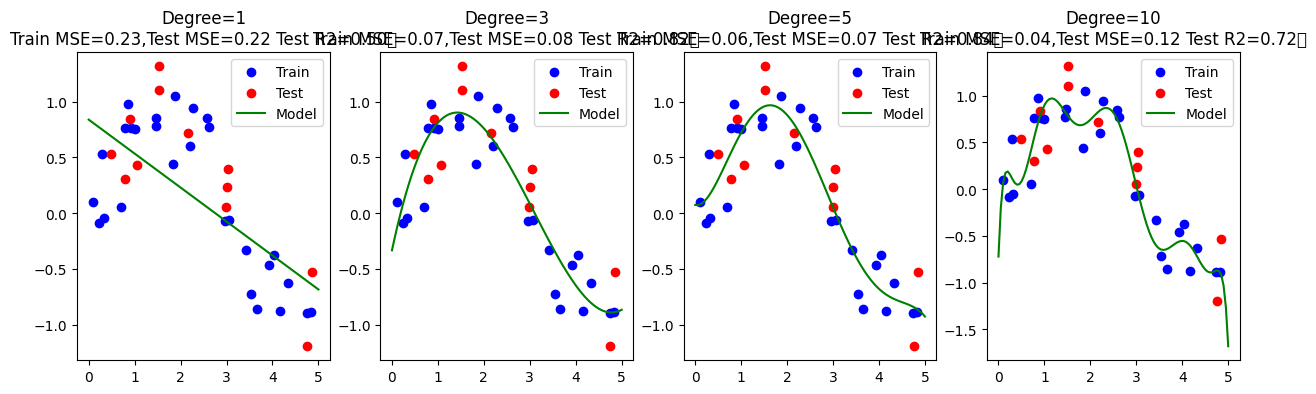

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
np.random.seed(42)
X=np.sort(5*np.random.rand(40,1),axis=0)
y=np.sin(X).ravel()+0.3*np.random.randn(40)
X_train, X_test,y_train,y_test=train_test_split(X,y,test_size=0.3, random_state=42)
degrees=[1,3,5,10]
plt.figure(figsize=(15,4))
for i,d in enumerate(degrees):
  poly=PolynomialFeatures(degree=d)
  X_poly_train=poly.fit_transform(X_train)
  X_poly_test=poly.transform(X_test)
  model=LinearRegression()
  model.fit(X_poly_train,y_train)
  y_train_pred=model.predict(X_poly_train)
  y_test_pred=model.predict(X_poly_test)
  train_error= mean_squared_error(y_train,y_train_pred)
  test_error=mean_squared_error(y_test,y_test_pred)
  train_r2=r2_score(y_train,y_train_pred)
  test_r2=r2_score(y_test,y_test_pred)
  print(f"\nPolynomial Degree {d}")
  print(f" Training MSE: {train_error:.4f}")
  print(f" Testing MSE: {test_error:.4f}")
  print(f" Training R2: {train_r2:.4f}")
  print(f" Testing R2: {test_r2:.4f}")
  plt.subplot(1,4,i+1)
  plt.scatter(X_train,y_train,color="blue",label="Train")
  plt.scatter(X_test,y_test,color="red",label="Test")
  X_plot=np.linspace(0,5,100).reshape(-1,1)
  plt.plot(X_plot,model.predict(poly.transform(X_plot)),color="green",label="Model")
  plt.title(f"Degree={d}\nTrain MSE={train_error:.2f},Test MSE={test_error:.2f} Test R2={test_r2:.2f}\t")
  plt.legend()
plt.show()


# 4. Lasso and Ridge Regression

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f"Dataset loaded successfully with shape: {df.shape}")

# Splitting features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Feature scaling (important for Ridge & Lasso)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training data shape: {x_train.shape}, Testing data shape: {x_test.shape}")

# ----------- Ridge Regression -----------
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)

y_pred_ridge = ridge.predict(x_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# ----------- Lasso Regression -----------
lasso = Lasso(alpha=0.1)
lasso.fit(x_train, y_train)

y_pred_lasso = lasso.predict(x_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

# Results
print("\n--- Ridge Regression ---")
print(f"MSE: {mse_ridge:.4f}")
print(f"R2 Score: {r2_ridge:.4f}")

print("\n--- Lasso Regression ---")
print(f"MSE: {mse_lasso:.4f}")
print(f"R2 Score: {r2_lasso:.4f}")

# Cross-validation
ridge_cv = cross_val_score(ridge, X_scaled, y, cv=10, scoring='r2')
lasso_cv = cross_val_score(lasso, X_scaled, y, cv=10, scoring='r2')

print(f"\nRidge CV R2 (10-fold): {ridge_cv.mean():.4f}")
print(f"Lasso CV R2 (10-fold): {lasso_cv.mean():.4f}")

# Coefficients comparison
print("\nRidge Coefficients:")
print(ridge.coef_)

print("\nLasso Coefficients:")
print(lasso.coef_)

Dataset loaded successfully with shape: (20640, 9)
Training data shape: (16512, 8), Testing data shape: (4128, 8)

--- Ridge Regression ---
MSE: 0.5559
R2 Score: 0.5758

--- Lasso Regression ---
MSE: 0.6796
R2 Score: 0.4814

Ridge CV R2 (10-fold): 0.5110
Lasso CV R2 (10-fold): 0.3578

Ridge Coefficients:
[ 0.85231009  0.12246004 -0.3048709   0.37081855 -0.00227294 -0.03662725
 -0.89588451 -0.86816501]

Lasso Coefficients:
[ 0.70918587  0.10647473 -0.          0.         -0.         -0.
 -0.01147904 -0.        ]


In [ ]:
from sklearn.linear_model import Ridge,Lasso
from sklearn.linear_model import RidgeCV,LassoCV
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
ridge=Ridge(alpha=10)
lasso=Lasso(alpha=0.001)
ridge.fit(x_train_scaled,y_train)
lasso.fit(x_train_scaled,y_train)
ridge_pred=ridge.predict(x_test_scaled)
lasso_pred=lasso.predict(x_test_scaled)
print(f"Ridge MSE:{mean_squared_error(y_test,ridge_pred):.4f}")
print(f"Ridge R2 score:{r2_score(y_test,ridge_pred):.4f}")
print(f"Lasso MSE:{mean_squared_error(y_test,lasso_pred):.4f}")
print(f"Lasso R2 score:{r2_score(y_test,lasso_pred):.4f}")


alphas=[0.001,0.01,0.1,1,10]
ridge_cv=RidgeCV(alphas=alphas,cv=5)
lasso_cv=LassoCV(alphas=alphas,cv=5)
ridge_cv.fit(x_train_scaled,y_train)
lasso_cv.fit(x_train_scaled,y_train)
print(f"\nRidge CV best alpha:{ridge_cv.alpha_:.4f}")
print(f"Lasso CV best alpha:{lasso_cv.alpha_:.4f}")

Ridge MSE:0.5555
Ridge R2 score:0.5761
Lasso MSE:0.5545
Lasso R2 score:0.5769

Ridge CV best alpha:0.0010
Lasso CV best alpha:0.0010


# 5. Logistic Regression

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Load dataset
data = load_breast_cancer(as_frame=True)
df = data.frame

print(f"Dataset loaded successfully with shape: {df.shape}")

# Splitting features and target
X = df.drop('target', axis=1)
y = df['target']

# Train-test split (80-20)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {x_train.shape}, Testing data shape: {x_test.shape}")

# Create and train Logistic Regression model
model = LogisticRegression(max_iter=10000)
model.fit(x_train, y_train)

# Predictions
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# Extract TP, TN, FP, FN
tn, fp, fn, tp = cm.ravel()

# Additional metrics
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
error = 1 - accuracy

print("\n--- Model Evaluation ---\n")
print(f"Accuracy: {accuracy:.4f}")
print(f"Error Rate: {error:.4f}")
print(f"AUC Score: {auc:.4f}")

print(f"\nTP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)

# Cross-validation (k=10)
cv_scores = cross_val_score(model, X, y, cv=10, scoring='accuracy')
print(f"\nCross-validation Accuracy (10-fold): {cv_scores.mean():.4f}")

Dataset loaded successfully with shape: (569, 31)
Training data shape: (455, 30), Testing data shape: (114, 30)

--- Model Evaluation ---

Accuracy: 0.9561
Error Rate: 0.0439
AUC Score: 0.9977

TP: 70, TN: 39, FP: 4, FN: 1
Recall: 0.9859
Specificity: 0.9070

Confusion Matrix:
[[39  4]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Cross-validation Accuracy (10-fold): 0.9543


# 6. Artificial Neural Network

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Load dataset
data = load_breast_cancer(as_frame=True)
df = data.frame

print(f"Dataset loaded successfully with shape: {df.shape}")

# Splitting features and target
X = df.drop('target', axis=1)
y = df['target']

# Feature scaling (important for ANN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training data shape: {x_train.shape}, Testing data shape: {x_test.shape}")

# Create and train ANN model
model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
model.fit(x_train, y_train)

# Predictions
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# Extract TP, TN, FP, FN
tn, fp, fn, tp = cm.ravel()

# Additional metrics
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
error = 1 - accuracy

print("\n--- Model Evaluation ---\n")
print(f"Accuracy: {accuracy:.4f}")
print(f"Error Rate: {error:.4f}")
print(f"AUC Score: {auc:.4f}")

print(f"\nTP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)

# Cross-validation (k=10)
cv_scores = cross_val_score(model, X_scaled, y, cv=10, scoring='accuracy')
print(f"\nCross-validation Accuracy (10-fold): {cv_scores.mean():.4f}")

Dataset loaded successfully with shape: (569, 31)
Training data shape: (455, 30), Testing data shape: (114, 30)

--- Model Evaluation ---

Accuracy: 0.9737
Error Rate: 0.0263
AUC Score: 0.9957

TP: 70, TN: 41, FP: 2, FN: 1
Recall: 0.9859
Specificity: 0.9535

Confusion Matrix:
[[41  2]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Cross-validation Accuracy (10-fold): 0.9737


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load data
iris = load_iris()
x = iris.data
y = iris.target

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Scaling (important for ANN)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# ANN model
ann = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, random_state=42)

# Train
ann.fit(x_train_scaled, y_train)

# Predict
y_pred = ann.predict(x_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"ANN Accuracy: {accuracy:.4f}")

# Cross-validation
cv_scores = cross_val_score(ann, scaler.fit_transform(x), y, cv=5, scoring='accuracy')
print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

# Confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ANN Accuracy: 1.0000
CV scores: [0.96666667 1.         0.93333333 0.93333333 1.        ]
Mean CV accuracy: 0.9666666666666668

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



# 7. K-NN Classifier

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Load dataset
data = load_breast_cancer(as_frame=True)
df = data.frame

print(f"Dataset loaded successfully with shape: {df.shape}")

# Splitting features and target
X = df.drop('target', axis=1)
y = df['target']

# Train-test split (80-20)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {x_train.shape}, Testing data shape: {x_test.shape}")

# Create and train KNN model
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train, y_train)

# Predictions
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# Extract TP, TN, FP, FN
tn, fp, fn, tp = cm.ravel()

# Additional metrics
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
error = 1 - accuracy

print("\n--- Model Evaluation ---\n")
print(f"Accuracy: {accuracy:.4f}")
print(f"Error Rate: {error:.4f}")
print(f"AUC Score: {auc:.4f}")

print(f"\nTP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)

# Cross-validation (k=10)
cv_scores = cross_val_score(model, X, y, cv=10, scoring='accuracy')
print(f"\nCross-validation Accuracy (10-fold): {cv_scores.mean():.4f}")


# --- NEW SECTION: Finding the Optimal K ---
print("\n--- Tuning K Value ---")
for k in range(1, 11):
    temp_model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(temp_model, X, y, cv=5)
    print(f"K={k}, Mean Accuracy={scores.mean():.4f}")

Dataset loaded successfully with shape: (569, 31)
Training data shape: (455, 30), Testing data shape: (114, 30)

--- Model Evaluation ---

Accuracy: 0.9561
Error Rate: 0.0439
AUC Score: 0.9959

TP: 71, TN: 38, FP: 5, FN: 0
Recall: 1.0000
Specificity: 0.8837

Confusion Matrix:
[[38  5]
 [ 0 71]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94        43
           1       0.93      1.00      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114


Cross-validation Accuracy (10-fold): 0.9298

--- Tuning K Value ---
K=1, Mean Accuracy=0.9051
K=2, Mean Accuracy=0.9051
K=3, Mean Accuracy=0.9191
K=4, Mean Accuracy=0.9209
K=5, Mean Accuracy=0.9279
K=6, Mean Accuracy=0.9244
K=7, Mean Accuracy=0.9262
K=8, Mean Accuracy=0.9279
K=9, Mean Accuracy=0.9315
K=10, Mean Accuracy=0.9315


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
iris=load_iris()
x=iris.data
y=iris.target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"KNN Model Accuracy:{accuracy:.4f}")
print("\nSample Predictions")
for i in range(5):
  print(f"Actual:{iris.target_names[y_test[i]]},Predicted:{iris.target_names[y_pred[i]]}")

KNN Model Accuracy:1.0000

Sample Predictions
Actual:versicolor,Predicted:versicolor
Actual:setosa,Predicted:setosa
Actual:virginica,Predicted:virginica
Actual:versicolor,Predicted:versicolor
Actual:versicolor,Predicted:versicolor


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize

# Cross Validation
cv_scores = cross_val_score(knn, x, y, cv=5, scoring='accuracy')
print("\nCross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report (Precision, Recall, F1)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# AUC (multi-class)
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_pred_bin = label_binarize(y_pred, classes=[0,1,2])
auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr')
print("AUC Score:", auc)

# Error Rate
error = 1 - accuracy
print("Error Rate:", error)


Cross-validation scores: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Mean CV accuracy: 0.9733333333333334

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

AUC Score: 1.0
Error Rate: 0.0


# 8. Decision tree classification

Dataset loaded successfully with shape: (569, 31)
Training data shape: (455, 30), Testing data shape: (114, 30)


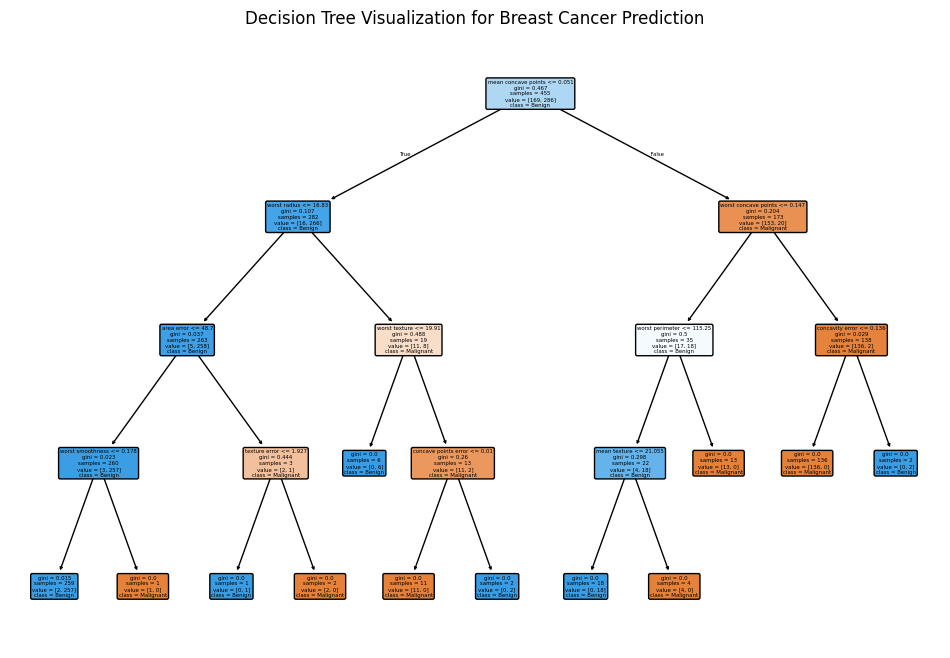


--- Model Evaluation ---

Accuracy: 0.9474
Error Rate: 0.0526
AUC Score: 0.9358

TP: 68, TN: 40, FP: 3, FN: 3
Recall: 0.9577
Specificity: 0.9302

Confusion Matrix:
[[40  3]
 [ 3 68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


Cross-validation Accuracy (10-fold): 0.9211


In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn import tree
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer(as_frame=True)
df = data.frame

print(f"Dataset loaded successfully with shape: {df.shape}")

# Splitting features and target
X = df.drop('target', axis=1)
y = df['target']

# Train-test split (80-20)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {x_train.shape}, Testing data shape: {x_test.shape}")

# Create and train Decision Tree model
model = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
model.fit(x_train, y_train)

#visualize the tree
plt.figure(figsize=(12,8))
tree.plot_tree(model,
               feature_names=X.columns, # This shows actual feature names instead of X[0], X[1]
               class_names=['Malignant', 'Benign'], # Shows the category names
               filled=True,
               rounded=True)
plt.title("Decision Tree Visualization for Breast Cancer Prediction")
plt.show()

# Predictions
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# Extract TP, TN, FP, FN
tn, fp, fn, tp = cm.ravel()

# Additional metrics
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
error = 1 - accuracy

print("\n--- Model Evaluation ---\n")
print(f"Accuracy: {accuracy:.4f}")
print(f"Error Rate: {error:.4f}")
print(f"AUC Score: {auc:.4f}")

print(f"\nTP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)

# Cross-validation (k=10)
cv_scores = cross_val_score(model, X, y, cv=10, scoring='accuracy')
print(f"\nCross-validation Accuracy (10-fold): {cv_scores.mean():.4f}")

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
iris=load_iris()
x=iris.data
y=iris.target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
dt= DecisionTreeClassifier(criterion='log_loss',splitter='best',max_depth=None,min_samples_split=2,min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.01, monotonic_cst=None)
dt.fit(x_train,y_train)
y_pred = dt.predict(x_test)


accuracy=accuracy_score(y_test,y_pred)
cv_scores = cross_val_score(dt, x, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print(f"Accuracy:{accuracy:.4f}")

Cross-validation scores: [0.96666667 0.96666667 0.9        0.96666667 1.        ]
Mean CV accuracy: 0.9600000000000002
Accuracy:1.0000


[Text(0.3076923076923077, 0.9285714285714286, 'x[2] <= 2.45\nlog_loss = 1.585\nsamples = 120\nvalue = [40, 41, 39]'),
 Text(0.23076923076923078, 0.7857142857142857, 'log_loss = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.2692307692307693, 0.8571428571428572, 'True  '),
 Text(0.38461538461538464, 0.7857142857142857, 'x[2] <= 4.75\nlog_loss = 1.0\nsamples = 80\nvalue = [0, 41, 39]'),
 Text(0.34615384615384615, 0.8571428571428572, '  False'),
 Text(0.15384615384615385, 0.6428571428571429, 'x[3] <= 1.65\nlog_loss = 0.179\nsamples = 37\nvalue = [0, 36, 1]'),
 Text(0.07692307692307693, 0.5, 'log_loss = 0.0\nsamples = 36\nvalue = [0, 36, 0]'),
 Text(0.23076923076923078, 0.5, 'log_loss = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6153846153846154, 0.6428571428571429, 'x[3] <= 1.75\nlog_loss = 0.519\nsamples = 43\nvalue = [0, 5, 38]'),
 Text(0.38461538461538464, 0.5, 'x[2] <= 4.95\nlog_loss = 1.0\nsamples = 8\nvalue = [0, 4, 4]'),
 Text(0.3076923076923077, 0.35714285714285715, 'log_los

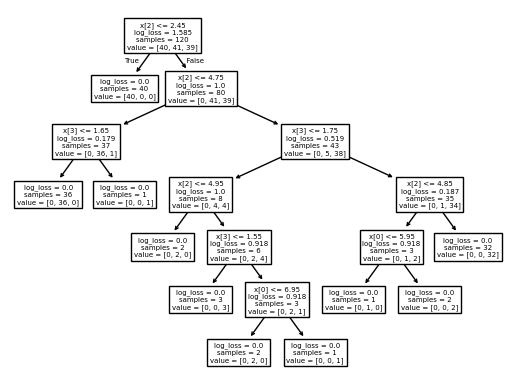

In [ ]:
tree.plot_tree(dt)

# 9. SVM Classification

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Load dataset
data = load_breast_cancer(as_frame=True)
df = data.frame

print(f"Dataset loaded successfully with shape: {df.shape}")

# Splitting features and target
X = df.drop('target', axis=1)
y = df['target']

# Feature Scaling (important for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training data shape: {x_train.shape}, Testing data shape: {x_test.shape}")

# Create and train SVM model
model = SVC(kernel='rbf', probability=True)
model.fit(x_train, y_train)

# Predictions
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# Extract TP, TN, FP, FN
tn, fp, fn, tp = cm.ravel()

# Additional metrics
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
error = 1 - accuracy

print("\n--- Model Evaluation ---\n")
print(f"Accuracy: {accuracy:.4f}")
print(f"Error Rate: {error:.4f}")
print(f"AUC Score: {auc:.4f}")

print(f"\nTP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)

# Cross-validation (k=10)
cv_scores = cross_val_score(model, X_scaled, y, cv=10, scoring='accuracy')
print(f"\nCross-validation Accuracy (10-fold): {cv_scores.mean():.4f}")

Dataset loaded successfully with shape: (569, 31)
Training data shape: (455, 30), Testing data shape: (114, 30)

--- Model Evaluation ---

Accuracy: 0.9737
Error Rate: 0.0263
AUC Score: 0.9974

TP: 70, TN: 41, FP: 2, FN: 1
Recall: 0.9859
Specificity: 0.9535

Confusion Matrix:
[[41  2]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Cross-validation Accuracy (10-fold): 0.9771


# 10. K-means clustering

Dataset loaded successfully with shape: (150, 5)


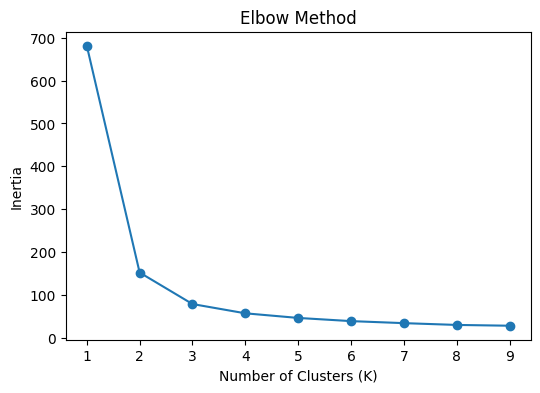


--- Model Evaluation ---

Number of clusters: 3
Silhouette Score: 0.5528

Cluster Centers:
[[5.9016129  2.7483871  4.39354839 1.43387097]
 [5.006      3.428      1.462      0.246     ]
 [6.85       3.07368421 5.74210526 2.07105263]]


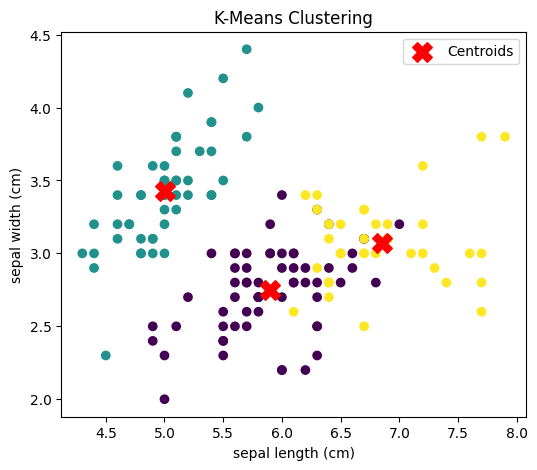

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset
data = load_iris(as_frame=True)
df = data.frame

print(f"Dataset loaded successfully with shape: {df.shape}")

# Use only features (no target)
X = df.drop('target', axis=1)


# --- THE ELBOW METHOD  ---
inertia = []
K_range = range(1, 10)

for k_val in K_range: # I changed this to k_val to avoid conflict
    temp_model = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    temp_model.fit(X)
    inertia.append(temp_model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


# Create KMeans model
k = 3
model = KMeans(n_clusters=k, random_state=42, n_init=10)
model.fit(X)

# Cluster labels
labels = model.labels_

# Evaluation using Silhouette Score
sil_score = silhouette_score(X, labels)

print("\n--- Model Evaluation ---\n")
print(f"Number of clusters: {k}")
print(f"Silhouette Score: {sil_score:.4f}")

# Cluster centers
print("\nCluster Centers:")
print(model.cluster_centers_)

# Visualization (first two features)
plt.figure(figsize=(6,5))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap='viridis')
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
            color='red', marker='X', s=200, label='Centroids')
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("K-Means Clustering")
plt.legend()
plt.show()

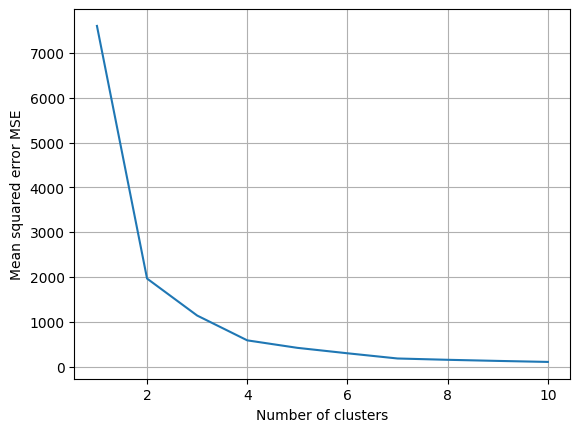

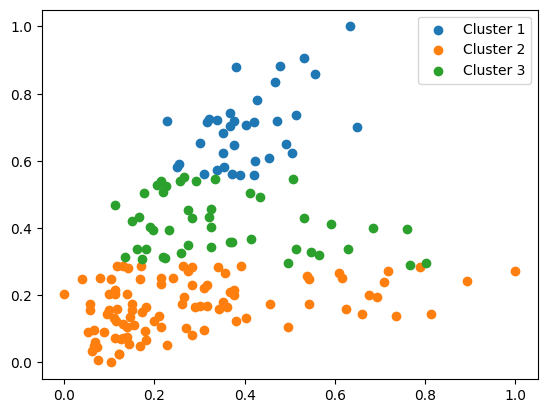

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error

wine = load_wine()
X = pd.DataFrame(wine.data, columns = wine.feature_names)
X[:5]


mse = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
  kmeans.fit(X)
  mse.append(mean_squared_error(X, kmeans.cluster_centers_[kmeans.labels_]))

plt.plot(range(1,11),mse)
plt.grid(True)
plt.xlabel("Number of clusters")
plt.ylabel("Mean squared error MSE")
plt.show()

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
labels = kmeans.labels_
labels

scaler = MinMaxScaler()
normalized_X = scaler.fit_transform(X)

for j in range(3):
    plt.scatter(normalized_X[labels == j, 9], normalized_X[labels == j, 12], label=f'Cluster {j+1}')
    plt.legend()

# 11. Hierarchical clustering

Dataset loaded successfully with shape: (150, 5)

--- Model Evaluation ---

Number of clusters: 3
Silhouette Score: 0.5543


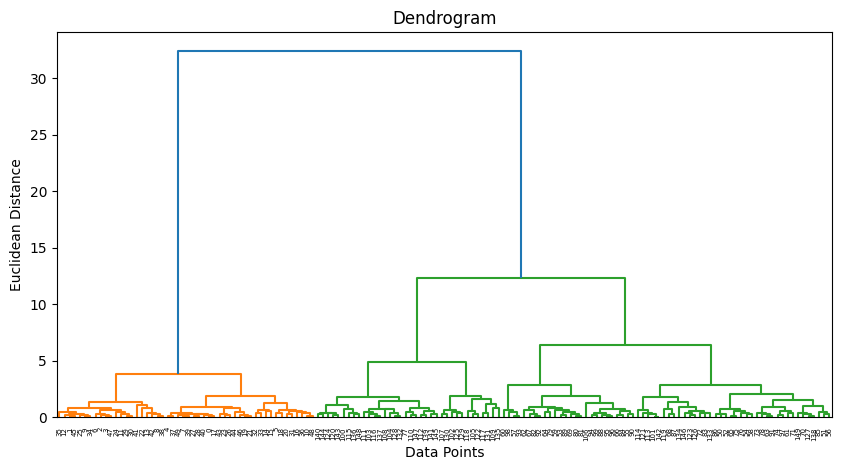

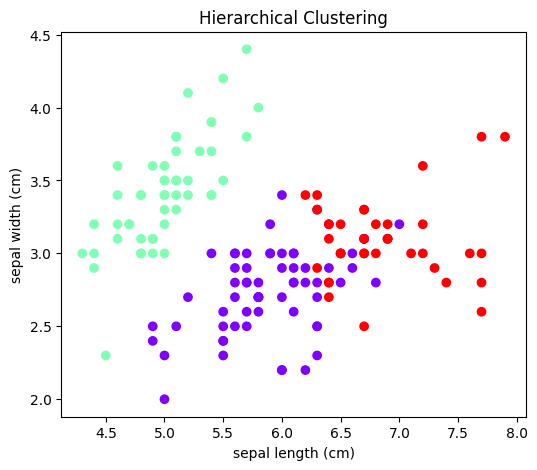

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# Load dataset
data = load_iris(as_frame=True)
df = data.frame

print(f"Dataset loaded successfully with shape: {df.shape}")

# Use only features
X = df.drop('target', axis=1)

# Create model
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X)

# Evaluation
sil_score = silhouette_score(X, labels)

print("\n--- Model Evaluation ---\n")
print(f"Number of clusters: 3")
print(f"Silhouette Score: {sil_score:.4f}")

# Plot Dendrogram
plt.figure(figsize=(10,5))
sch.dendrogram(sch.linkage(X, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

# Visualization (first two features)
plt.figure(figsize=(6,5))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap='rainbow')
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("Hierarchical Clustering")
plt.show()

Dataset loaded successfully with shape: (178, 13)

--- Model Evaluation ---

Number of clusters: 3
Silhouette Score: 0.2948


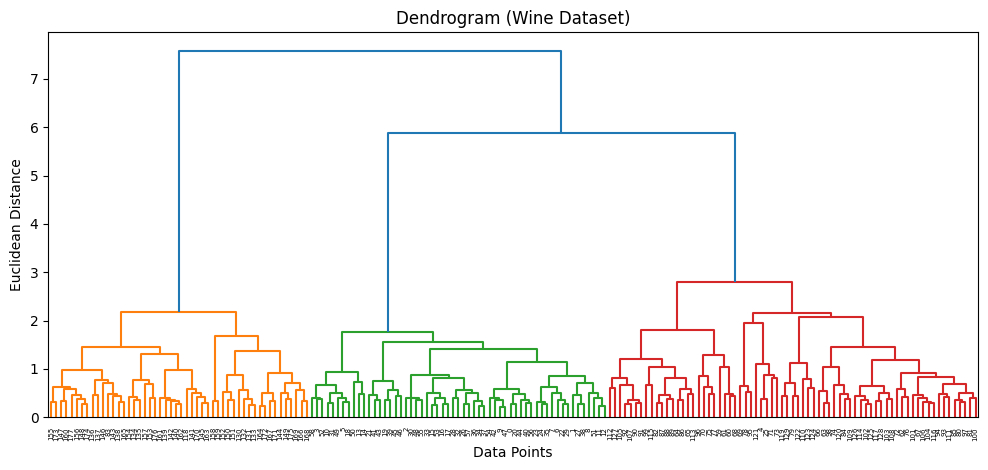

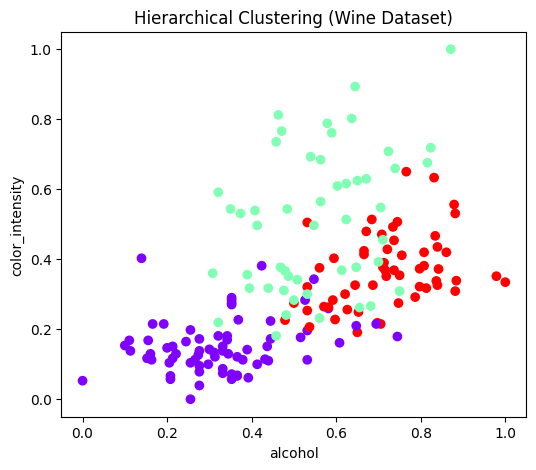

Done


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# Load dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)

print(f"Dataset loaded successfully with shape: {X.shape}")

# Feature scaling (IMPORTANT for hierarchical clustering)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Create model
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X_scaled)

# Evaluation
sil_score = silhouette_score(X_scaled, labels)

print("\n--- Model Evaluation ---\n")
print(f"Number of clusters: 3")
print(f"Silhouette Score: {sil_score:.4f}")

# Dendrogram
plt.figure(figsize=(12,5))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram (Wine Dataset)")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

# Visualization (choose 2 features, e.g., alcohol & color_intensity)
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 9], c=labels, cmap='rainbow')
plt.xlabel(X.columns[0])  # alcohol
plt.ylabel(X.columns[9])  # color_intensity
plt.title("Hierarchical Clustering (Wine Dataset)")
plt.show()
print("Done")

In [ ]:
# End of File